<a href="https://colab.research.google.com/github/DarshiniMahesh/AI-Practice/blob/main/Garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 01: Setting up Kaggle API to download our Garbage Dataset

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

Step 2: Download our Garbage Dataset from Kaggle

In [ ]:
# Download Dataset
!kaggle datasets download -d darshinimahesh/garbage-classification-dataset-darshini
print("✅ Dataset Downloaded!")

Dataset URL: https://www.kaggle.com/datasets/darshinimahesh/garbage-classification-dataset-darshini
License(s): CC0-1.0
garbage-classification-dataset-darshini.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ Dataset Downloaded!


Step 3: Unzip the dataset and check all folders

In [ ]:
import os

# Check what files are present
files = os.listdir('/content')
print("📁 Files in Colab:")
for f in files:
    print(" -", f)

📁 Files in Colab:
 - .config
 - .ipynb_checkpoints
 - .gradio
 - garbage_data
 - kaggle.json
 - garbage-classification-dataset-darshini.zip
 - sample_data


In [ ]:
# Unzip Dataset with correct filename
!unzip -q -o garbage-classification-dataset-darshini.zip -d garbage_data
print("✅ Unzip Done!")

import os

# Find correct path automatically
base = 'garbage_data'
for root, dirs, files in os.walk(base):
    if len(dirs) >= 4:
        DATA_PATH = root
        break

print("✅ Dataset Path Found:", DATA_PATH)
print("📁 Classes:", os.listdir(DATA_PATH))

✅ Unzip Done!
✅ Dataset Path Found: garbage_data/Garbage classification
📁 Classes: ['cardboard', 'paper', 'plastic', 'metal', 'glass', 'trash']


Step 4: Install and Import all required libraries

In [ ]:
# Install Gradio
!pip install gradio -q

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import gradio as gr
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from PIL import Image

print("✅ All Libraries Imported!")
print("TensorFlow Version:", tf.__version__)

✅ All Libraries Imported!
TensorFlow Version: 2.19.0


Step 5: Visualize some images from our dataset — Let's see what our garbage looks like!

/tmp/ipykernel_9777/750324450.py:18: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


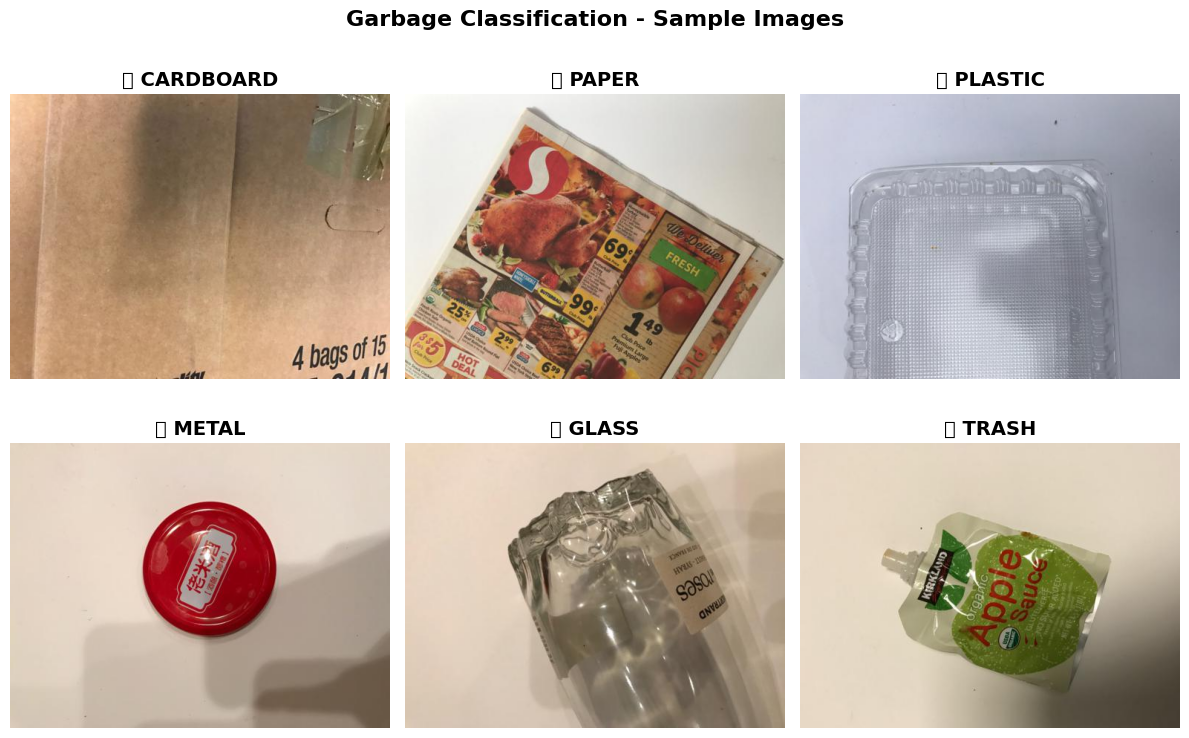

✅ Images Visualized!


In [ ]:
# Visualize Sample Images
import matplotlib.image as mpimg

classes = os.listdir(DATA_PATH)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, category in enumerate(classes):
    folder = os.path.join(DATA_PATH, category)
    img_file = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_file)
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"🗑️ {category.upper()}", fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Garbage Classification - Sample Images", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Images Visualized!")

Step 6: Preprocess the images — Resize, Normalize and Split into Train & Validation

In [ ]:
# Preprocess Images
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixels 0-1
    validation_split=0.2,    # 80% train 20% validation
    rotation_range=15,       # Slight rotation
    zoom_range=0.1,          # Slight zoom
    horizontal_flip=True     # Flip images
)

train_data = datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

CLASS_NAMES = list(train_data.class_indices.keys())
print("✅ Data Preprocessed!")
print("📁 Classes:", CLASS_NAMES)
print("🖼️ Training Images:", train_data.samples)
print("🖼️ Validation Images:", val_data.samples)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
✅ Data Preprocessed!
📁 Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
🖼️ Training Images: 2024
🖼️ Validation Images: 503


Step 7: Build our CNN Model — This is the brain of our classifier!

In [ ]:
# Build CNN Model
model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 4
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')  # 6 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("✅ Model Built!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,635,526 (13.87 MB)

 Trainable params: 3,634,566 (13.86 MB)

 Non-trainable params: 960 (3.75 KB)

✅ Model Built!


In [ ]:
# Train Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

print("✅ Model Training Complete!")

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 405ms/step - accuracy: 0.3488 - loss: 3.7694 - val_accuracy: 0.2346 - val_loss: 2.6122 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - accuracy: 0.4066 - loss: 2.2059 - val_accuracy: 0.2147 - val_loss: 2.1899 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 291ms/step - accuracy: 0.4496 - loss: 1.7273 - val_accuracy: 0.2425 - val_loss: 1.8178 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - accuracy: 0.4565 - loss: 1.6187 - val_accuracy: 0.2565 - val_loss: 1.8340 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - accuracy: 0.5035 - loss: 1.4936 - val_accuracy: 0.2565 - val_loss: 1.8253 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 275ms/step - accuracy: 0.5163 - loss: 1.3677 - val_accuracy: 0.3002 - val_loss: 1.8504 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 258ms/step - accuracy: 0.5390 - loss: 1.

Step 9: Plot Accuracy and Loss graphs — See how well our model learned!

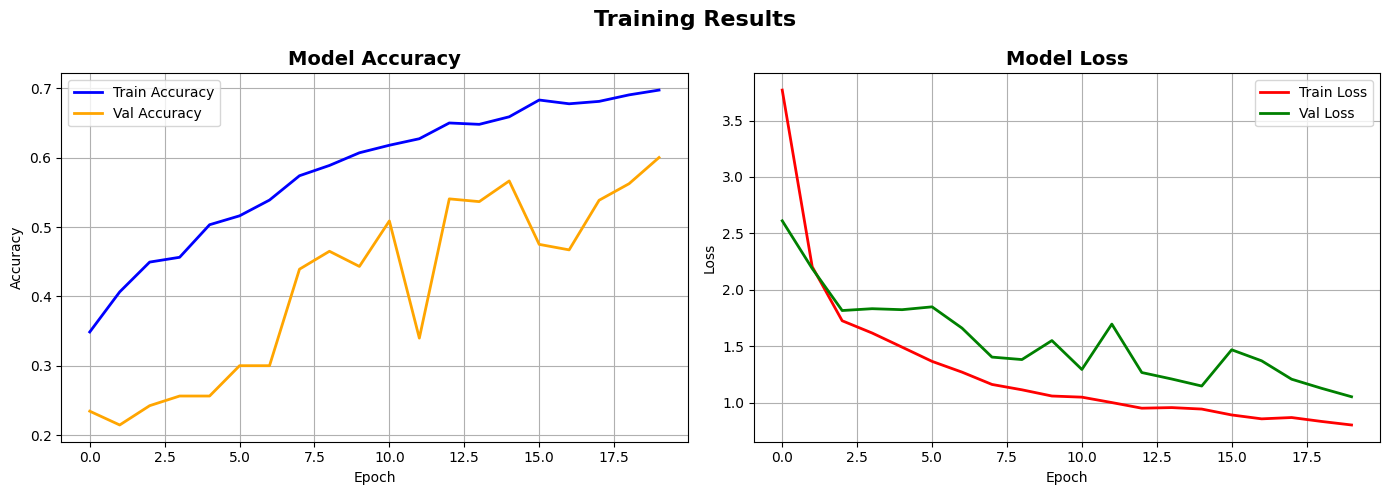

✅ Graphs Plotted!


In [ ]:
# Plot Accuracy and Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss Plot
axes[1].plot(history.history['loss'], label='Train Loss', color='red', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', color='green', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training Results", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Graphs Plotted!")

Step 10: Save the trained model for future use

In [ ]:
# Save Model
model.save('garbage_classifier.h5')
print("✅ Model Saved as garbage_classifier.h5")

✅ Model Saved as garbage_classifier.h5


Step 11: Launch Gradio UI — Upload any garbage image and see the prediction!

In [ ]:
# Gradio UI
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

# Load saved model
model = load_model('garbage_classifier.h5')

CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

EMOJI_MAP = {
    'cardboard': '📦',
    'glass':     '🪟',
    'metal':     '🔩',
    'paper':     '📄',
    'plastic':   '🧴',
    'trash':     '🗑️'
}

TIPS_MAP = {
    'cardboard': '♻️ Flatten and recycle it!',
    'glass':     '♻️ Clean and put in glass bin!',
    'metal':     '♻️ Put in metal recycling bin!',
    'paper':     '♻️ Recycle it in paper bin!',
    'plastic':   '♻️ Check recycling number first!',
    'trash':     '🗑️ Put in general waste bin!'
}

def predict_garbage(img):
    # Preprocess
    img = img.resize((150, 150))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)[0]
    confidence = np.max(predictions) * 100
    predicted_class = CLASS_NAMES[np.argmax(predictions)]

    emoji = EMOJI_MAP[predicted_class]
    tip = TIPS_MAP[predicted_class]

    # Build result
    result = f"{emoji} **{predicted_class.upper()}**\n\n"
    result += f"🎯 Confidence: {confidence:.2f}%\n\n"
    result += f"{tip}"

    # All class probabilities
    all_probs = {CLASS_NAMES[i]: float(predictions[i]) for i in range(len(CLASS_NAMES))}

    return result, all_probs

# Build Gradio Interface
with gr.Blocks(title="🗑️ Garbage Classifier", theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # 🗑️ Garbage Classification AI
    ### Upload an image of garbage and I will tell you what type it is!
    """)

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", label="📸 Upload Garbage Image")
            predict_btn = gr.Button("🔍 Classify Garbage!", variant="primary", size="lg")

        with gr.Column():
            output_text = gr.Markdown(label="🎯 Prediction Result")
            output_label = gr.Label(label="📊 All Class Probabilities", num_top_classes=6)

    gr.Markdown("""
    ### 📚 Classes I can identify:
    | Emoji | Class | Tip |
    |-------|-------|-----|
    | 📦 | Cardboard | Flatten and recycle |
    | 🪟 | Glass | Clean and recycle |
    | 🔩 | Metal | Put in metal bin |
    | 📄 | Paper | Recycle in paper bin |
    | 🧴 | Plastic | Check recycling number |
    | 🗑️ | Trash | General waste bin |
    """)

    predict_btn.click(
        fn=predict_garbage,
        inputs=input_image,
        outputs=[output_text, output_label]
    )

app.launch(share=True, debug=True)